Successfully loaded Chicago data using fastparquet engine
Total unique amenities: 719
Total amenity occurrences: 90641


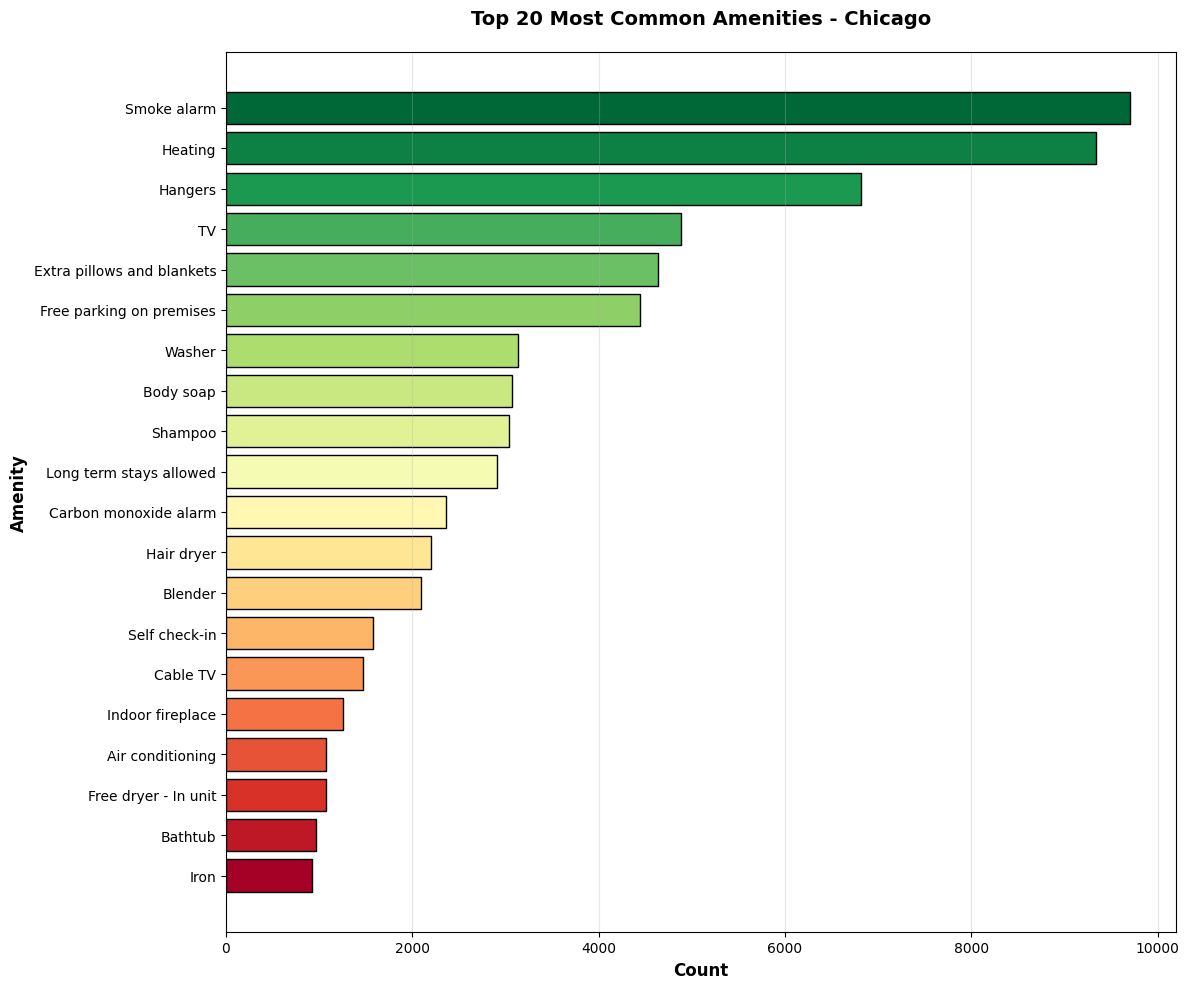


Top 20 Most Common Amenities:
                   Amenity  Count
               Smoke alarm   9706
                   Heating   9340
                   Hangers   6820
                        TV   4887
Extra pillows and blankets   4632
  Free parking on premises   4443
                    Washer   3137
                 Body soap   3073
                   Shampoo   3042
   Long term stays allowed   2906
     Carbon monoxide alarm   2361
                Hair dryer   2205
                   Blender   2090
             Self check-in   1578
                  Cable TV   1476
          Indoor fireplace   1261
          Air conditioning   1075
      Free dryer - In unit   1072
                   Bathtub    970
                      Iron    923


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import sys

# Adjust the filename if needed
parquet_path = Path("chicago.parquet")
if not parquet_path.exists():
    sys.exit(f"Parquet file not found: {parquet_path.resolve()}")

# Load Chicago data
df_chicago = None
try:
    df_chicago = pd.read_parquet(parquet_path, engine="fastparquet")
    print("Successfully loaded Chicago data using fastparquet engine")
except Exception as e:
    print(f"fastparquet failed: {e}")
    try:
        df_chicago = pd.read_parquet(parquet_path, engine="pyarrow")
        print("Successfully loaded Chicago data using pyarrow engine")
    except Exception as e2:
        sys.exit(f"Error loading file with both engines: {e2}")

# Extract all amenities from the amenities_array column
all_amenities_chicago = []
for amenities in df_chicago["amenities_array"].dropna():
    if isinstance(amenities, list):
        all_amenities_chicago.extend(amenities)

# Count occurrences of each amenity
amenity_counts_chicago = Counter(all_amenities_chicago)

# Create DataFrame for easier manipulation
amenities_df_chicago = pd.DataFrame(amenity_counts_chicago.items(), columns=["Amenity", "Count"])
amenities_df_chicago = amenities_df_chicago.sort_values("Count", ascending=False)
print(f"Total unique amenities: {len(amenities_df_chicago)}")
print(f"Total amenity occurrences: {amenities_df_chicago['Count'].sum()}")

# Create bar chart for Top 20 Most Common Amenities with gradient color
plt.figure(figsize=(12, 10))
top_20_chicago = amenities_df_chicago.head(20).sort_values("Count", ascending=True)
# Create gradient from red (bottom) to green (top)
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(top_20_chicago)))

plt.barh(top_20_chicago["Amenity"], top_20_chicago["Count"], color=colors, edgecolor="black")
plt.xlabel("Count", fontsize=12, fontweight="bold")
plt.ylabel("Amenity", fontsize=12, fontweight="bold")
plt.title("Top 20 Most Common Amenities - Chicago", fontsize=14, fontweight="bold", pad=20)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("top_20_amenities_chicago.png")
plt.show()

# Display summary statistics
print("\nTop 20 Most Common Amenities:")
print(amenities_df_chicago.head(20).to_string(index=False))

Successfully loaded Los Angeles data using fastparquet engine
Total unique amenities: 1310
Total amenity occurrences: 369015


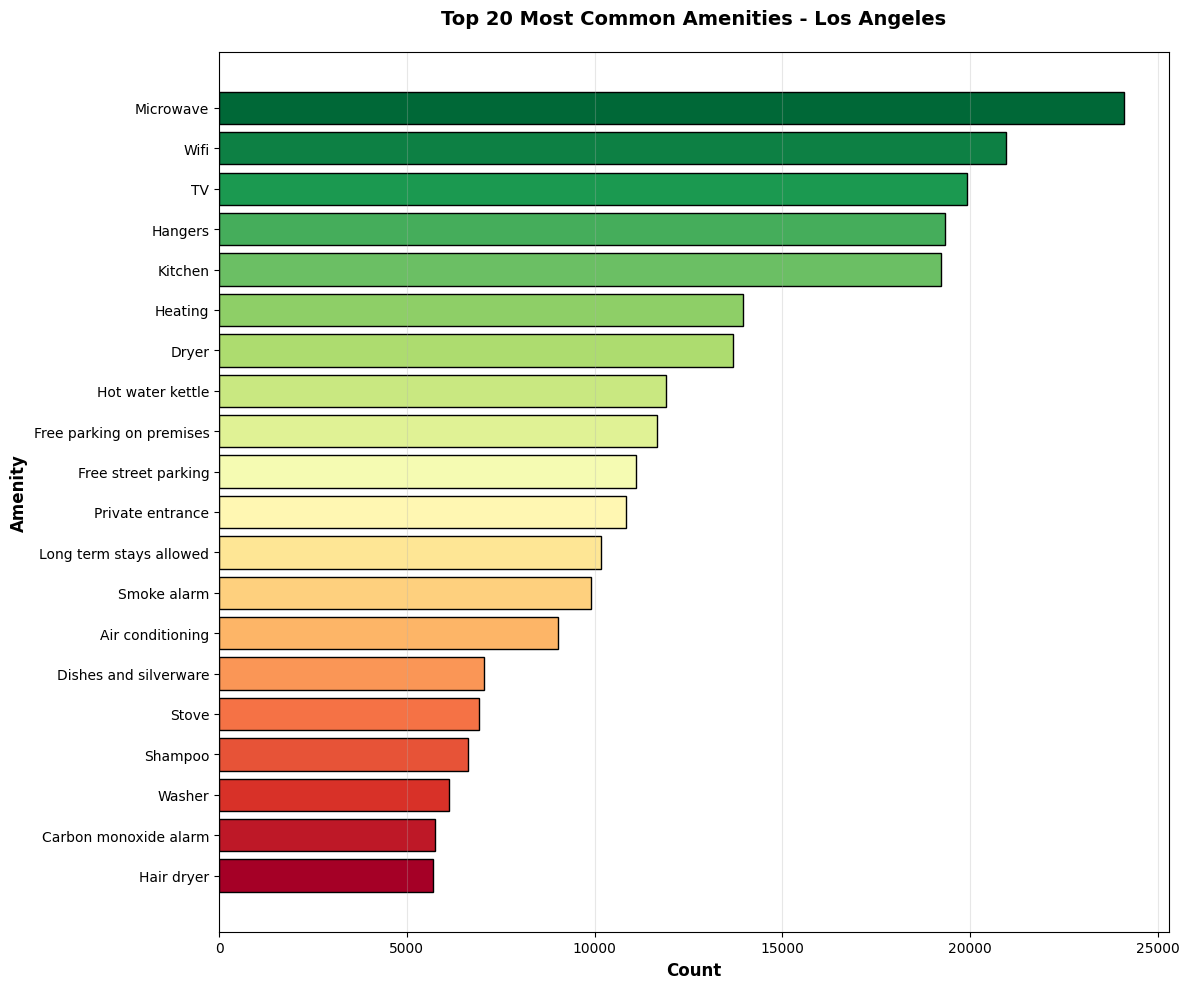


Top 20 Most Common Amenities:
                 Amenity  Count
               Microwave  24090
                    Wifi  20967
                      TV  19923
                 Hangers  19343
                 Kitchen  19225
                 Heating  13950
                   Dryer  13674
        Hot water kettle  11893
Free parking on premises  11652
     Free street parking  11102
        Private entrance  10845
 Long term stays allowed  10182
             Smoke alarm   9909
        Air conditioning   9032
   Dishes and silverware   7047
                   Stove   6916
                 Shampoo   6627
                  Washer   6133
   Carbon monoxide alarm   5761
              Hair dryer   5695


In [7]:
# Adjust the filename if needed
parquet_path = Path("los-angeles.parquet")
if not parquet_path.exists():
    sys.exit(f"Parquet file not found: {parquet_path.resolve()}")

# Load Los Angeles data
df_la = None
try:
    df_la = pd.read_parquet(parquet_path, engine="fastparquet")
    print("Successfully loaded Los Angeles data using fastparquet engine")
except Exception as e:
    print(f"fastparquet failed: {e}")
    try:
        df_la = pd.read_parquet(parquet_path, engine="pyarrow")
        print("Successfully loaded Los Angeles data using pyarrow engine")
    except Exception as e2:
        sys.exit(f"Error loading file with both engines: {e2}")

# Extract all amenities from the amenities_array column
all_amenities_la = []
for amenities in df_la["amenities_array"].dropna():
    if isinstance(amenities, list):
        all_amenities_la.extend(amenities)

# Count occurrences of each amenity
amenity_counts_la = Counter(all_amenities_la)

# Create DataFrame for easier manipulation
amenities_df_la = pd.DataFrame(amenity_counts_la.items(), columns=["Amenity", "Count"])
amenities_df_la = amenities_df_la.sort_values("Count", ascending=False)

print(f"Total unique amenities: {len(amenities_df_la)}")
print(f"Total amenity occurrences: {amenities_df_la['Count'].sum()}")

# Create bar chart for Top 20 Most Common Amenities with gradient color
plt.figure(figsize=(12, 10))
top_20_la = amenities_df_la.head(20).sort_values("Count", ascending=True)

# Create gradient from red (bottom) to green (top)
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(top_20_la)))

plt.barh(top_20_la["Amenity"], top_20_la["Count"], color=colors, edgecolor="black")
plt.xlabel("Count", fontsize=12, fontweight="bold")
plt.ylabel("Amenity", fontsize=12, fontweight="bold")
plt.title("Top 20 Most Common Amenities - Los Angeles", fontsize=14, fontweight="bold", pad=20)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("top_20_amenities_los_angeles.png")
plt.show()

# Display summary statistics
print("\nTop 20 Most Common Amenities:")
print(amenities_df_la.head(20).to_string(index=False))

Successfully loaded New York City data using fastparquet engine
Total unique amenities: 1114
Total amenity occurrences: 343426


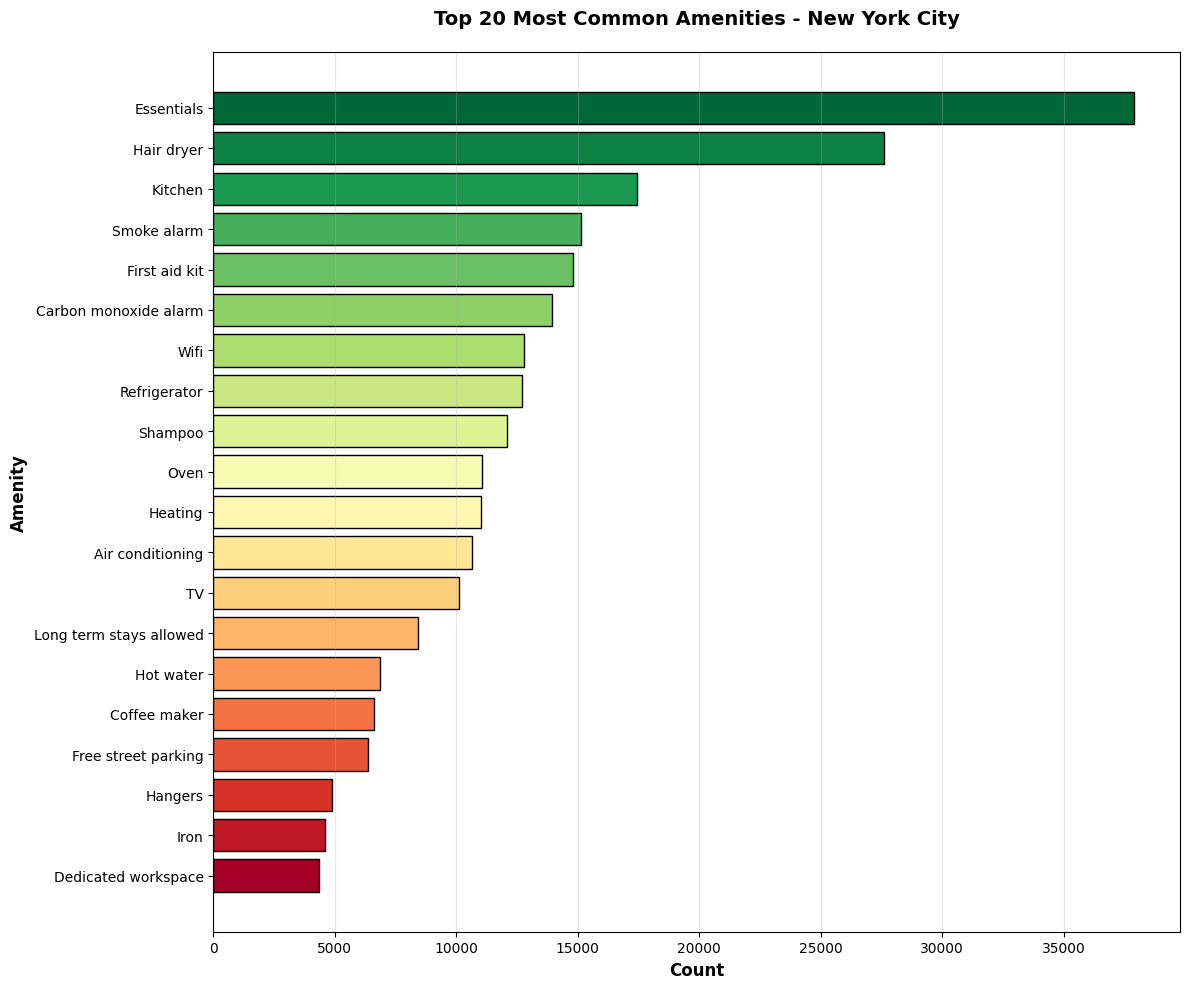


Top 20 Most Common Amenities:
                Amenity  Count
             Essentials  37889
             Hair dryer  27616
                Kitchen  17436
            Smoke alarm  15139
          First aid kit  14797
  Carbon monoxide alarm  13952
                   Wifi  12797
           Refrigerator  12704
                Shampoo  12087
                   Oven  11044
                Heating  11016
       Air conditioning  10632
                     TV  10099
Long term stays allowed   8415
              Hot water   6866
           Coffee maker   6601
    Free street parking   6379
                Hangers   4899
                   Iron   4583
    Dedicated workspace   4336


In [8]:
# Adjust the filename if needed
parquet_path = Path("new-york-city.parquet")
if not parquet_path.exists():
    sys.exit(f"Parquet file not found: {parquet_path.resolve()}")

# Load Los Angeles data
df_la = None
try:
    df_la = pd.read_parquet(parquet_path, engine="fastparquet")
    print("Successfully loaded New York City data using fastparquet engine")
except Exception as e:
    print(f"fastparquet failed: {e}")
    try:
        df_la = pd.read_parquet(parquet_path, engine="pyarrow")
        print("Successfully loaded New York City data using pyarrow engine")
    except Exception as e2:
        sys.exit(f"Error loading file with both engines: {e2}")

# Extract all amenities from the amenities_array column
all_amenities_la = []
for amenities in df_la["amenities_array"].dropna():
    if isinstance(amenities, list):
        all_amenities_la.extend(amenities)

# Count occurrences of each amenity
amenity_counts_la = Counter(all_amenities_la)

# Create DataFrame for easier manipulation
amenities_df_la = pd.DataFrame(amenity_counts_la.items(), columns=["Amenity", "Count"])
amenities_df_la = amenities_df_la.sort_values("Count", ascending=False)

print(f"Total unique amenities: {len(amenities_df_la)}")
print(f"Total amenity occurrences: {amenities_df_la['Count'].sum()}")

# Create bar chart for Top 20 Most Common Amenities with gradient color
plt.figure(figsize=(12, 10))
top_20_la = amenities_df_la.head(20).sort_values("Count", ascending=True)

# Create gradient from red (bottom) to green (top)
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(top_20_la)))

plt.barh(top_20_la["Amenity"], top_20_la["Count"], color=colors, edgecolor="black")
plt.xlabel("Count", fontsize=12, fontweight="bold")
plt.ylabel("Amenity", fontsize=12, fontweight="bold")
plt.title("Top 20 Most Common Amenities - New York City", fontsize=14, fontweight="bold", pad=20)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("top_20_amenities_new_york_city.png")
plt.show()

# Display summary statistics
print("\nTop 20 Most Common Amenities:")
print(amenities_df_la.head(20).to_string(index=False))

Skipping new-york.parquet: Not found: new-york.parquet
Total unique amenities (all files): 1706
Total amenity occurrences (all files): 459656
Total unique amenities (all files): 1706
Total amenity occurrences (all files): 459656


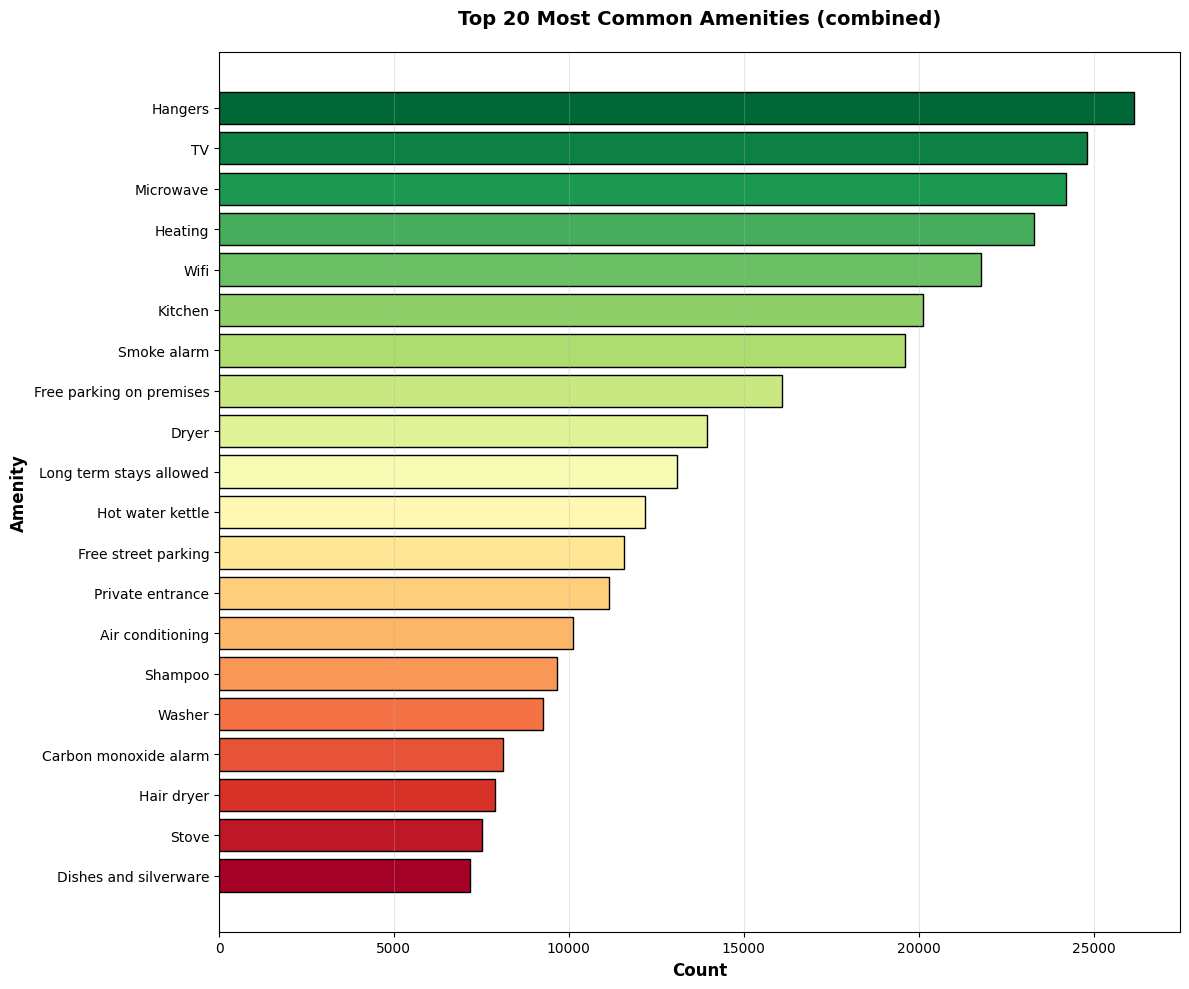


Top 20 Most Common Amenities (combined):
                 Amenity  Count
                 Hangers  26163
                      TV  24810
               Microwave  24215
                 Heating  23290
                    Wifi  21794
                 Kitchen  20136
             Smoke alarm  19615
Free parking on premises  16095
                   Dryer  13954
 Long term stays allowed  13088
        Hot water kettle  12164
     Free street parking  11564
        Private entrance  11147
        Air conditioning  10107
                 Shampoo   9669
                  Washer   9270
   Carbon monoxide alarm   8122
              Hair dryer   7900
                   Stove   7519
   Dishes and silverware   7183


In [9]:
# List all your parquet files here
parquet_files = [
    Path("los-angeles.parquet"),
    Path("new-york.parquet"),
    Path("chicago.parquet"),
]

def load_parquet(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")
    try:
        return pd.read_parquet(path, engine="fastparquet")
    except Exception:
        return pd.read_parquet(path, engine="pyarrow")

# Aggregate amenities across all files
all_amenities = []
for path in parquet_files:
    try:
        df = load_parquet(path)
    except Exception as exc:
        print(f"Skipping {path}: {exc}")
        continue
    for amenities in df["amenities_array"].dropna():
        if isinstance(amenities, list):
            all_amenities.extend(amenities)

# Count and select top N
amenity_counts = Counter(all_amenities)
amenities_df = (
    pd.DataFrame(amenity_counts.items(), columns=["Amenity", "Count"])
    .sort_values("Count", ascending=False)
)
top_n = 20
top_df = amenities_df.head(top_n).sort_values("Count", ascending=True)

print(f"Total unique amenities (all files): {len(amenities_df)}")
print(f"Total amenity occurrences (all files): {amenities_df['Count'].sum()}")

# Plot combined top N
plt.figure(figsize=(12, 10))
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(top_df)))
plt.barh(top_df["Amenity"], top_df["Count"], color=colors, edgecolor="black")
plt.xlabel("Count", fontsize=12, fontweight="bold")
plt.ylabel("Amenity", fontsize=12, fontweight="bold")
plt.title(f"Top {top_n} Most Common Amenities (combined)", fontsize=14, fontweight="bold", pad=20)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("top_20_amenities_combined.png")
plt.show()

# Optional: print the table
print(f"\nTop {top_n} Most Common Amenities (combined):")
print(top_df.sort_values("Count", ascending=False).to_string(index=False))

In [10]:
# List your parquet files here
parquet_files = [
    Path("los-angeles.parquet"),
    Path("new-york-city.parquet"),
    Path("chicago.parquet"),
]

def load_parquet(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")
    try:
        return pd.read_parquet(path, engine="fastparquet")
    except Exception:
        return pd.read_parquet(path, engine="pyarrow")

def extract_amenity_set(df: pd.DataFrame) -> set:
    amenity_set = set()
    for amenities in df["amenities_array"].dropna():
        if isinstance(amenities, list):
            amenity_set.update(amenities)
    return amenity_set

def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

# Build per-city amenity sets
city_sets = {}
for path in parquet_files:
    try:
        df = load_parquet(path)
    except Exception as exc:
        print(f"Skipping {path}: {exc}")
        continue
    city_name = path.stem  # e.g., "los-angeles"
    city_sets[city_name] = extract_amenity_set(df)

# Compute pairwise Jaccard matrix
cities = list(city_sets.keys())
jaccard_matrix = pd.DataFrame(index=cities, columns=cities, dtype=float)

for i, c1 in enumerate(cities):
    for j, c2 in enumerate(cities):
        if j < i:
            # symmetric reuse
            jaccard_matrix.loc[c1, c2] = jaccard_matrix.loc[c2, c1]
        else:
            jaccard_matrix.loc[c1, c2] = jaccard(city_sets[c1], city_sets[c2])

print("\nPairwise Jaccard similarity (unique amenities):")
print(jaccard_matrix.to_string(float_format=lambda x: f"{x:.3f}"))

# Optional: inspect set sizes
sizes = {c: len(s) for c, s in city_sets.items()}
print("\nAmenity set sizes per city:")
print(pd.Series(sizes).to_string())


Pairwise Jaccard similarity (unique amenities):
               los-angeles  new-york-city  chicago
los-angeles          1.000          0.185    0.189
new-york-city        0.185          1.000    0.180
chicago              0.189          0.180    1.000

Amenity set sizes per city:
los-angeles      1310
new-york-city    1114
chicago           719
